In [1]:
import os
os.environ["QT_API"] = "pyqt5"
os.environ["MNE_3D_OPTION_ANTIALIAS"] = "1"

In [2]:
import numpy as np
import mne
from mne.simulation import simulate_raw, simulate_sparse_stc, add_noise, add_eog
from mne import make_ad_hoc_cov

In [104]:

SFREQ        = 256        # Hz
DURATION_MIN = 5          # minutes
EPOCH_DUR    = 10.0       # seconds per tiled source epoch
N_DIPOLES    = 6          # sparse cortical sources
ALPHA_HZ     = 10.0       # dominant resting frequency
SEED         = 42
OUTPUT       = "resting_eeg_sphere_raw.fif"

rng = np.random.RandomState(SEED)

In [105]:
print("Building channel info …")

montage = mne.channels.make_standard_montage("standard_1020")
ch_names = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T7','C3','Cz','C4','T8',
            'P7','P3','Pz','P4','P8',
            'O1','O2']

info = mne.create_info(ch_names=ch_names, sfreq=SFREQ, ch_types="eeg")
raw = mne.io.RawArray(np.zeros((len(ch_names), 1)), info, verbose=False)
raw.set_montage(montage)
raw = raw.set_eeg_reference("average", projection=False, verbose=False)

Building channel info …


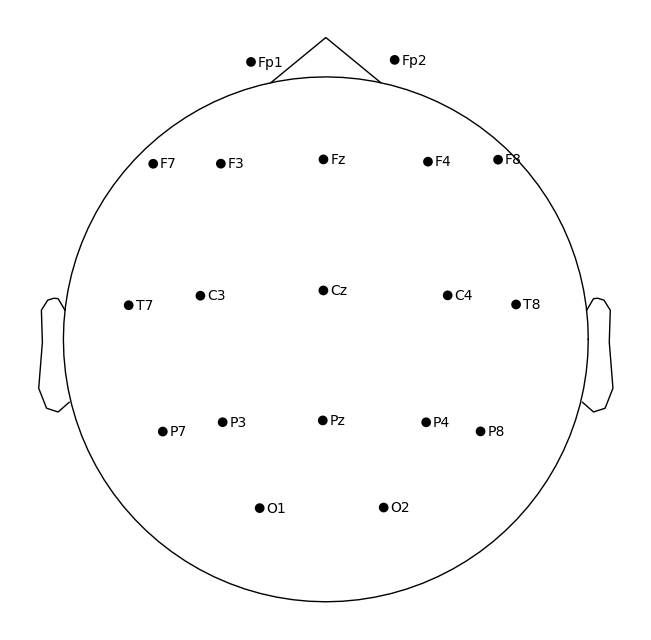

In [9]:
electrode_fig = raw.plot_sensors(show_names = True)

In [106]:
print("Building spherical conductor model …")
sphere = mne.make_sphere_model("auto","auto", raw.info        # outer skull radius
)


Building spherical conductor model …
Fitted sphere radius:         95.6 mm
Origin head coordinates:      -0.9 15.8 45.4 mm
Origin device coordinates:    -0.9 15.8 45.4 mm

Equiv. model fitting -> RV = 0.00347455 %%
mu1 = 0.944856    lambda1 = 0.136823
mu2 = 0.667779    lambda2 = 0.683693
mu3 = -0.294888    lambda3 = -0.0101468
Set up EEG sphere model with scalp radius    95.6 mm



In [7]:
print("Creating volume source space …")
src = mne.setup_volume_source_space(
    pos=15.0,                  # grid spacing in mm
    sphere=sphere,
    sphere_units="m",          # sphere object already in metres
    verbose=False,
)
print(f"  Source space: {src[0]['nuse']} active voxels")

Creating volume source space …
  Source space: 666 active voxels


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_13964\2294434764.py:2: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  src = mne.setup_volume_source_space(


In [8]:
print("Computing EEG forward solution (sphere) …")
fwd = mne.make_forward_solution(
    raw.info,
    trans=None,                # no head↔MRI transform needed for sphere
    src=src,
    bem=sphere,
    eeg=True,
    meg=False,
    verbose=False,
)
print(f"  Forward: {fwd['sol']['data'].shape} (channels × sources)")

Computing EEG forward solution (sphere) …
  Forward: (19, 1998) (channels × sources)


In [9]:
trans = mne.transforms.Transform("head", "mri", np.eye(4))
mne.viz.plot_alignment(
    info=raw.info,
    bem=sphere,
    trans=trans,
    eeg=[ 'projected'],  # <-- was: eeg=True
    dig=True,
    surfaces='head',
)

Using pyvistaqt 3d backend.
Channel types::	eeg: 19
Projecting sensors to the head surface


In [23]:

src = mne.setup_volume_source_space(sphere=sphere, pos=10.0)
mne.viz.plot_alignment(
    raw.info,
    trans=trans,
    eeg="projected",
    bem=sphere,
    src=src,
    dig=True,
    surfaces='head',
    show_axes=True,
)

Sphere                : origin at (0.0 0.0 0.0) mm
              radius  : 81.0 mm
grid                  : 10.0 mm
mindist               : 5.0 mm

Setting up the sphere...
Surface CM = (   0.0    0.0    0.0) mm
Surface fits inside a sphere with radius   81.0 mm
Surface extent:
    x =  -81.0 ...   81.0 mm
    y =  -81.0 ...   81.0 mm
    z =  -81.0 ...   81.0 mm
Grid extent:
    x =  -90.0 ...   90.0 mm
    y =  -90.0 ...   90.0 mm
    z =  -90.0 ...   90.0 mm
6859 sources before omitting any.
2205 sources after omitting infeasible sources not within 0.0 - 81.0 mm.
Source spaces are in MRI coordinates.
Checking that the sources are inside the surface and at least    5.0 mm away (will take a few...)
    366 source space point omitted because of the    5.0-mm distance limit.
1839 sources remaining after excluding the sources outside the surface and less than    5.0 mm inside.
Adjusting the neighborhood info.
Source space : MRI voxel -> MRI (surface RAS)
    0.010000 0.000000 0.000000    

C:\Users\ingrambz\AppData\Local\Temp\ipykernel_30320\781427587.py:1: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  src = mne.setup_volume_source_space(sphere=sphere, pos=10.0)


Channel types::	eeg: 19
Projecting sensors to the head surface


### Simulate Data

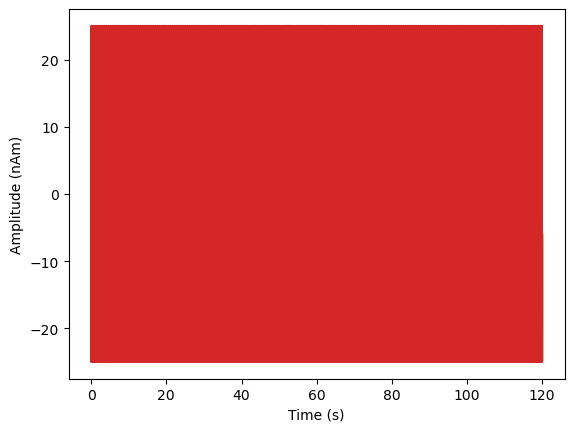

In [28]:
import matplotlib.pyplot as plt 
n_dipoles = 4  # number of dipoles to create
epoch_duration = 2.0  # duration of each epoch/event
n = 0  # harmonic number
rng = np.random.RandomState(0)  # random state (make reproducible)


def data_fun(times):
    return 25e-9 * np.sin(2 * np.pi * 10 * times)


sfreq = raw.info["sfreq"]  # sampling frequency (Hz)
duration = 120.0  # 2 minutes in seconds

n_samp = int(sfreq * duration)
times = np.arange(n_samp) / sfreq

src = fwd["src"]
stc = simulate_sparse_stc(
    src, n_dipoles=n_dipoles, times=times, data_fun=data_fun, random_state=rng
)

# look at our source data
fig, ax = plt.subplots(1)
ax.plot(times, 1e9 * stc.data.T)
ax.set(ylabel="Amplitude (nAm)", xlabel="Time (s)")
mne.viz.utils.plt_show()

In [62]:
stc = simulate_sparse_stc(
    fwd["src"],
    n_dipoles=1,
    times=times,
    data_fun=data_fun,
    random_state=0
)

In [63]:
raw.info

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, T7, C3, Cz, C4, T8, P7, P3, Pz, ...
 chs: 19 EEG
 custom_ref_applied: True
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 256.0 Hz
>

In [59]:
info = raw.info.copy()
info["dev_head_t"] = fwd["info"]["dev_head_t"]
raw_sim = simulate_raw(info, [stc] * 10, forward=fwd, verbose=True)
cov = make_ad_hoc_cov(raw_sim.info)
add_noise(raw_sim, cov, iir_filter=[0.2, -0.2, 0.04], random_state=rng)
#add_ecg(raw_sim, random_state=rng)
add_eog(raw_sim, random_state=rng)

Setting up raw simulation: 1 position, "cos2" interpolation
Event information not stored
    Interval 0.000–120.000 s
Setting up forward solutions
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    10 STC iterations provided
[done]
Adding noise to 19/19 channels (19 channels in cov)
Sphere                : origin at (0.0 0.0 0.0) mm
              radius  : 0.1 mm
Source location file  : dict()
Assuming input in millimeters
Assuming input in MRI coordinates

Positions (in meters) and orientations
2 sources
blink simulated and trace not stored
Setting up forward solutions


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_30320\2403221597.py:7: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  add_eog(raw_sim, random_state=rng)


In [60]:
raw_sim.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x263c4801c10) at 0x0000026409E51EC0>

Channels marked as bad:
none


Effective window size : 8.000 (s)


Plotting power spectral density (dB=True).


c:\Users\ingrambz\AppData\Local\mne-python\1.11.0_0\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


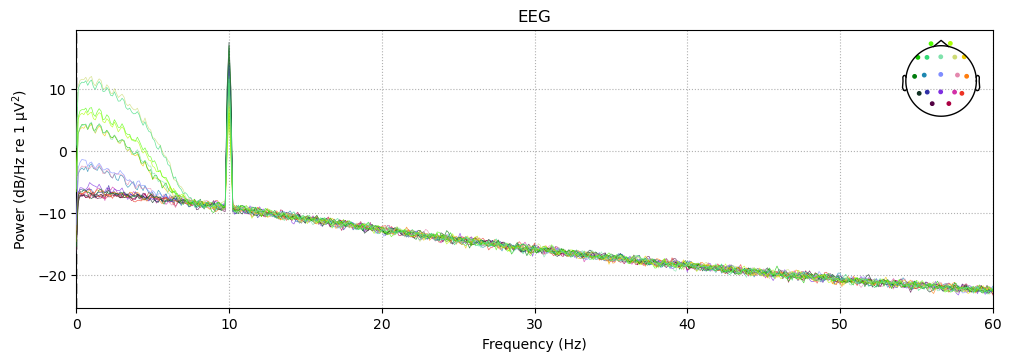

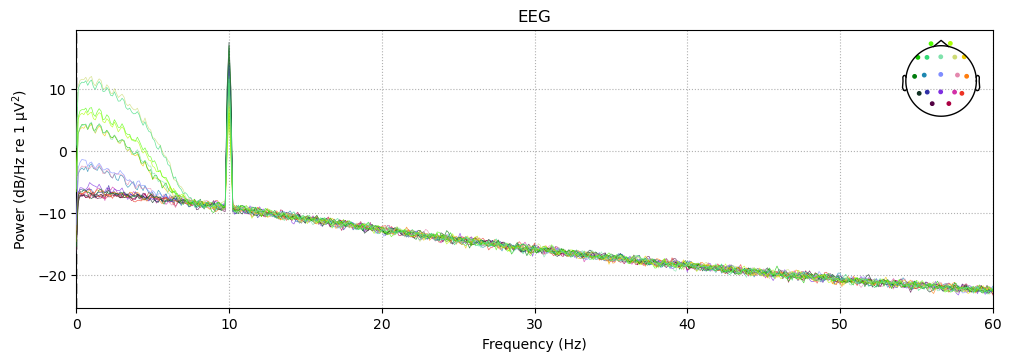

In [61]:
raw_sim.compute_psd(fmax = 60).plot(dB=True)

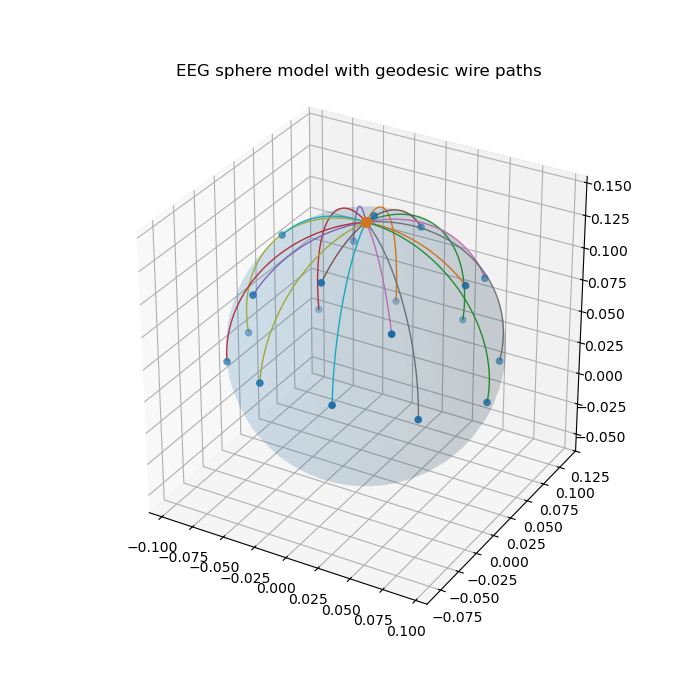

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import mne

%matplotlib widget

# =========================================================
# 1. SPHERE GEOMETRY (from your MNE model)
# =========================================================
center = np.array(sphere['r0'])
radius = max(layer['rad'] for layer in sphere['layers'])

# =========================================================
# 2. ELECTRODE POSITIONS (correct MNE-aligned version)
# =========================================================
coords = []
ch_names = []

for ch in raw.info['chs']:
    if ch['kind'] == mne.io.constants.FIFF.FIFFV_EEG_CH:
        loc = ch['loc'][:3]
        if not np.allclose(loc, 0):
            coords.append(loc)
            ch_names.append(ch['ch_name'])

coords = np.array(coords)

# =========================================================
# 3. PROJECT ELECTRODES TO SPHERE
# =========================================================
def project_to_sphere(points, center, radius):
    vecs = points - center
    vecs /= np.linalg.norm(vecs, axis=1, keepdims=True)
    return center + vecs * radius

coords_proj = project_to_sphere(coords, center, radius)

# =========================================================
# 4. GREAT CIRCLE ARC FUNCTION
# =========================================================
def great_circle_arc(p1, p2, center, radius, n=50):
    # shift to origin
    p1 = p1 - center
    p2 = p2 - center

    # normalize to unit sphere
    p1 = p1 / np.linalg.norm(p1)
    p2 = p2 / np.linalg.norm(p2)

    # angle between vectors
    omega = np.arccos(np.clip(np.dot(p1, p2), -1, 1))

    if omega < 1e-6:
        return np.tile(center + p1 * radius, (n, 1))

    t = np.linspace(0, 1, n)
    sin_omega = np.sin(omega)

    arc = (
        np.sin((1 - t) * omega)[:, None] * p1 +
        np.sin(t * omega)[:, None] * p2
    ) / sin_omega

    return center + arc * radius

# =========================================================
# 5. SPHERE SURFACE (for plotting)
# =========================================================
u = np.linspace(0, 2*np.pi, 60)
v = np.linspace(0, np.pi, 60)

x = center[0] + radius * np.outer(np.cos(u), np.sin(v))
y = center[1] + radius * np.outer(np.sin(u), np.sin(v))
z = center[2] + radius * np.outer(np.ones_like(u), np.cos(v))

# =========================================================
# 6. PLOT
# =========================================================
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# sphere
ax.plot_surface(x, y, z, alpha=0.1)

# electrodes
ax.scatter(coords_proj[:, 0],
           coords_proj[:, 1],
           coords_proj[:, 2],
           s=20)

# top of head (wire origin)
top = center + np.array([0, 0, radius])
ax.scatter(*top, s=50)

# =========================================================
# 7. WIRES (top → each electrode)
# =========================================================
for ep in coords_proj:
    arc = great_circle_arc(top, ep, center, radius)
    ax.plot(arc[:, 0], arc[:, 1], arc[:, 2], linewidth=1)

# aesthetics
ax.set_box_aspect([1, 1, 1])
ax.set_title("EEG sphere model with geodesic wire paths")

plt.show()

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import mne

class SphereModel:
    @staticmethod
    def great_circle_arc(p1, p2, center, radius, n=50):
        p1 = p1 - center
        p2 = p2 - center
        p1 = p1 / np.linalg.norm(p1)
        p2 = p2 / np.linalg.norm(p2)
        omega = np.arccos(np.clip(np.dot(p1, p2), -1, 1))
        if omega < 1e-6:
            return np.tile(center + p1 * radius, (n, 1))
        t = np.linspace(0, 1, n)
        sin_omega = np.sin(omega)
        arc = (
            np.sin((1 - t) * omega)[:, None] * p1 +
            np.sin(t * omega)[:, None] * p2
        ) / sin_omega
        return center + arc * radius

    def __init__(self, info=None):
        print("Creating sphere model...")
        self.info = info
        mne_sphere = mne.make_sphere_model("auto", "auto", info)
        self.sphere = mne_sphere
        self.center = np.array(mne_sphere['r0'])
        self.radius = max(layer['rad'] for layer in mne_sphere['layers'])
        self.top = self.center + np.array([0, 0, self.radius])

        print("Storing electrode positions...")
        eeg_coords_orig = []
        ch_names = []
        for ch in info['chs']:
            if ch['kind'] == mne.io.constants.FIFF.FIFFV_EEG_CH:
                loc = ch['loc'][:3]
                if not np.allclose(loc, 0):
                    eeg_coords_orig.append(loc)
                    ch_names.append(ch['ch_name'])

        self.eeg_coords_orig = np.array(eeg_coords_orig)

        self.vecs = self.eeg_coords_orig - self.center
        self.vecs /= np.linalg.norm(self.vecs, axis=1, keepdims=True)
        self.eeg_coords_proj = self.center + self.vecs * self.radius

        self.wires = []
        for ep in self.eeg_coords_proj:
            arc = SphereModel.great_circle_arc(self.top, ep, self.center, self.radius)
            self.wires.append(arc)

    def plot_sphere(self):
        u = np.linspace(0, 2*np.pi, 60)
        v = np.linspace(0, np.pi, 60)
        x = self.center[0] + self.radius * np.outer(np.cos(u), np.sin(v))
        y = self.center[1] + self.radius * np.outer(np.sin(u), np.sin(v))
        z = self.center[2] + self.radius * np.outer(np.ones_like(u), np.cos(v))
        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111, projection='3d')
        ax.scatter(self.eeg_coords_proj[:, 0],
                   self.eeg_coords_proj[:, 1],
                   self.eeg_coords_proj[:, 2], s=20)
        ax.plot_surface(x, y, z, alpha=0.1)
        ax.set_box_aspect([1, 1, 1])
        ax.scatter(*self.top, s=50)
        for wire in self.wires:
            ax.plot(wire[:, 0], wire[:, 1], wire[:, 2], linewidth=1)
        ax.set_title("EEG sphere model with geodesic wire paths")
        plt.show()

    def simulate_eeg(self, alpha=True, blinks=True):
        self.src = mne.setup_volume_source_space(
            pos=15.0,
            sphere=self.sphere,
            sphere_units="m",
            verbose=False,
        )
        self.fwd = mne.make_forward_solution(
            self.info,
            trans=None,
            src=self.src,
            bem=self.sphere,
            eeg=True,
            meg=False,
            verbose=False,
        )

        n_dipoles = 1
        rng = np.random.RandomState(0)

        def data_fun(times):
            return 25e-9 * np.sin(2 * np.pi * 10 * times)

        sfreq = self.info["sfreq"]
        duration = 120.0
        n_samp = int(sfreq * duration)
        times = np.arange(n_samp) / sfreq

        stc = simulate_sparse_stc(
            self.src, n_dipoles=n_dipoles, times=times, data_fun=data_fun, random_state=rng
        )

        self.info["dev_head_t"] = self.fwd["info"]["dev_head_t"]
        raw_sim = simulate_raw(self.info, [stc] * 10, forward=self.fwd, verbose=True)
        cov = make_ad_hoc_cov(raw_sim.info)
        add_noise(raw_sim, cov, iir_filter=[0.2, -0.2, 0.04], random_state=rng)
        add_eog(raw_sim, random_state=rng)
        raw_sim.plot()

    def simulate_gradients(self, TR, echo_time, slices=32, multiband=2):
        print()

    def simulate_bcg(self, TR, echo_time, slices=32, multiband=2):
        print()


In [5]:
montage = mne.channels.make_standard_montage("standard_1020")
#montage = mne.channels.make_standard_montage("biosemi32")

info = mne.create_info(ch_names=montage.ch_names, sfreq=5000.0, ch_types="eeg")
info.set_montage(montage)

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fpz, Fp2, AF9, AF7, AF5, AF3, AF1, AFz, AF2, AF4, AF6, AF8, ...
 chs: 94 EEG
 custom_ref_applied: False
 dig: 97 items (3 Cardinal, 94 EEG)
 highpass: 0.0 Hz
 lowpass: 2500.0 Hz
 meas_date: unspecified
 nchan: 94
 projs: []
 sfreq: 5000.0 Hz
>

In [6]:
test = SphereModel(info)

Creating sphere model...
Fitted sphere radius:         98.4 mm
Origin head coordinates:      -1.0 13.9 39.1 mm
Origin device coordinates:    -1.0 13.9 39.1 mm

Equiv. model fitting -> RV = 0.00536245 %%
mu1 = 0.945195    lambda1 = 0.136558
mu2 = 0.662341    lambda2 = 0.721742
mu3 = 0.472128    lambda3 = -0.0479307
Set up EEG sphere model with scalp radius    98.4 mm

Storing electrode positions...


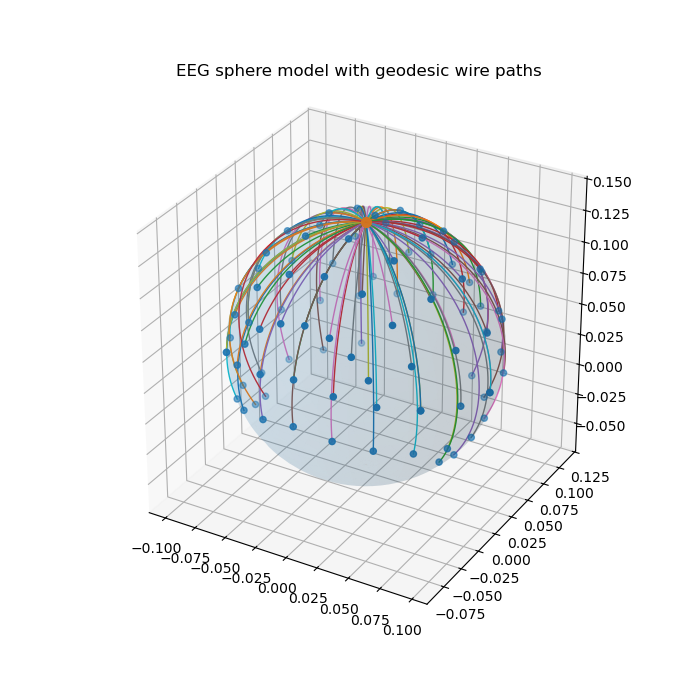

In [7]:
%matplotlib widget
test.plot_sphere()

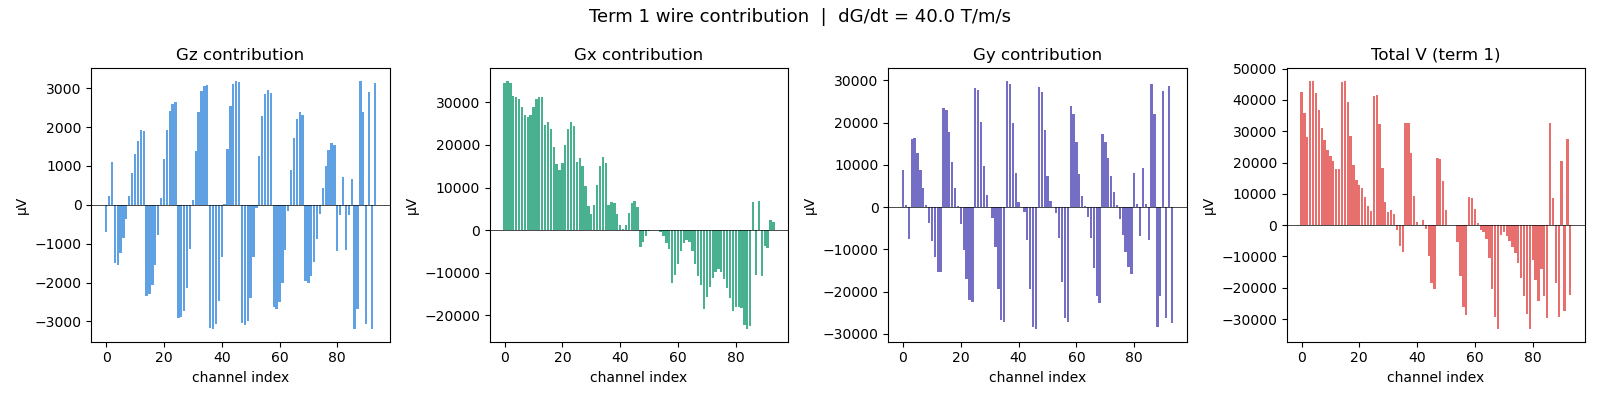


Max |V| across channels: 46123.11 µV
Mean |V|: 18203.85 µV


In [11]:
import numpy as np

def compute_term1(wires, dG_dt, gradient_axis='z'):
    """
    Compute term 1 of eq 2: ∫ ∂A/∂t · dl along each wire.
    
    Parameters
    ----------
    wires          : list of (N,3) arrays — wire paths from SphereModel
    dG_dt          : float — slew rate in T/m/s
    gradient_axis  : 'x', 'y', or 'z'
    
    Returns
    -------
    voltages : (n_channels,) array in µV
    """
    voltages = []

    for wire in wires:
        # step vectors along the wire — shape (N-1, 3)
        dl = np.diff(wire, axis=0)

        # midpoint positions at each step — shape (N-1, 3)
        pts = (wire[:-1] + wire[1:]) / 2
        x, y, z = pts[:,0], pts[:,1], pts[:,2]

        # ∂A/∂t at each midpoint — from appendix equations
        if gradient_axis == 'z':
            dAdt = np.column_stack([
                -0.5 * dG_dt * y * z,   # Ax  (eq A2)
                 0.5 * dG_dt * x * z,   # Ay
                 np.zeros_like(x)        # Az
            ])
        elif gradient_axis == 'x':
            dAdt = np.column_stack([
                -0.5  * dG_dt * x * y,          # Ax  (eq A4)
                 0.25 * dG_dt * (x**2 - y**2),  # Ay
                 dG_dt * y * z                   # Az
            ])
        elif gradient_axis == 'y':
            dAdt = np.column_stack([
                 0.25 * dG_dt * (x**2 - y**2),  # Ax  (eq A6)
                 0.5  * dG_dt * x * y,           # Ay
                -dG_dt * x * z                   # Az
            ])

        # dot product ∂A/∂t · dl at each step, then sum = line integral
        integrand = np.sum(dAdt * dl, axis=1)   # shape (N-1,)
        voltages.append(-np.sum(integrand))

    return np.array(voltages) * 1e6   # V → µV


# --- run it ---
dG_dt = 40.0   # T/m/s — typical EPI slew rate

V_z = compute_term1(test.wires, dG_dt, 'z')
V_x = compute_term1(test.wires, dG_dt, 'x')
V_y = compute_term1(test.wires, dG_dt, 'y')

V_total = V_z + V_x + V_y

# --- plot ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)

for ax, V, title, color in zip(
    axes,
    [V_z, V_x, V_y, V_total],
    ['Gz contribution', 'Gx contribution', 'Gy contribution', 'Total V (term 1)'],
    ['#378ADD', '#1D9E75', '#534AB7', '#E24B4A']
):
    ax.bar(range(len(V)), V, color=color, alpha=0.8)
    ax.axhline(0, color='k', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel('channel index')
    ax.set_ylabel('µV')

plt.suptitle(f'Term 1 wire contribution  |  dG/dt = {dG_dt} T/m/s', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nMax |V| across channels: {np.max(np.abs(V_total)):.2f} µV")
print(f"Mean |V|: {np.mean(np.abs(V_total)):.2f} µV")

C:\Users\brand\AppData\Local\Temp\ipykernel_40280\2576214093.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=8)


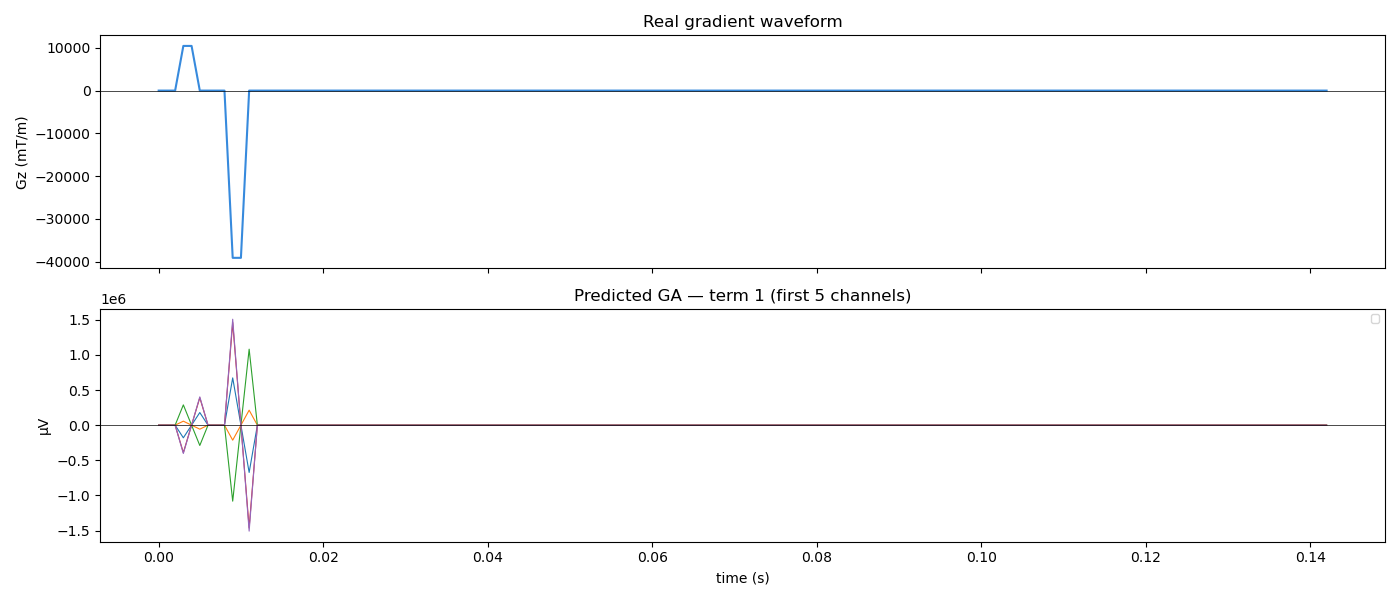

In [38]:
# your real sequence
# Gz is already a numpy array in T/m
# just tell me the sample rate
sfreq = 1000  # Hz — change this to whatever your sequence uses

# dG/dt — just the slope of the waveform
dGz_dt = np.diff(gz, prepend=gz[0]) * sfreq   # T/m/s

# scaling from wire geometry — computed once
scaling_z = compute_term1(test.wires, 1.0, 'z')

# predicted artefact — shape (n_channels, n_timepoints)
V_t = scaling_z[:, None] * dGz_dt[None, :]

# plot
t = np.arange(len(gz)) / sfreq

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

ax1.plot(t, gz * 1000, color='#378ADD')
ax1.set_ylabel('Gz (mT/m)')
ax1.set_title('Real gradient waveform')
ax1.axhline(0, color='k', lw=0.5)

for i in range(min(5, len(test.wires))):
    ax2.plot(t, V_t[i], lw=0.8)
ax2.set_ylabel('µV')
ax2.set_xlabel('time (s)')
ax2.set_title('Predicted GA — term 1 (first 5 channels)')
ax2.axhline(0, color='k', lw=0.5)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# CHECK POSITION OF THE HEAD IN THE VECTOR FIELD. WHAT SIZE HEAD.

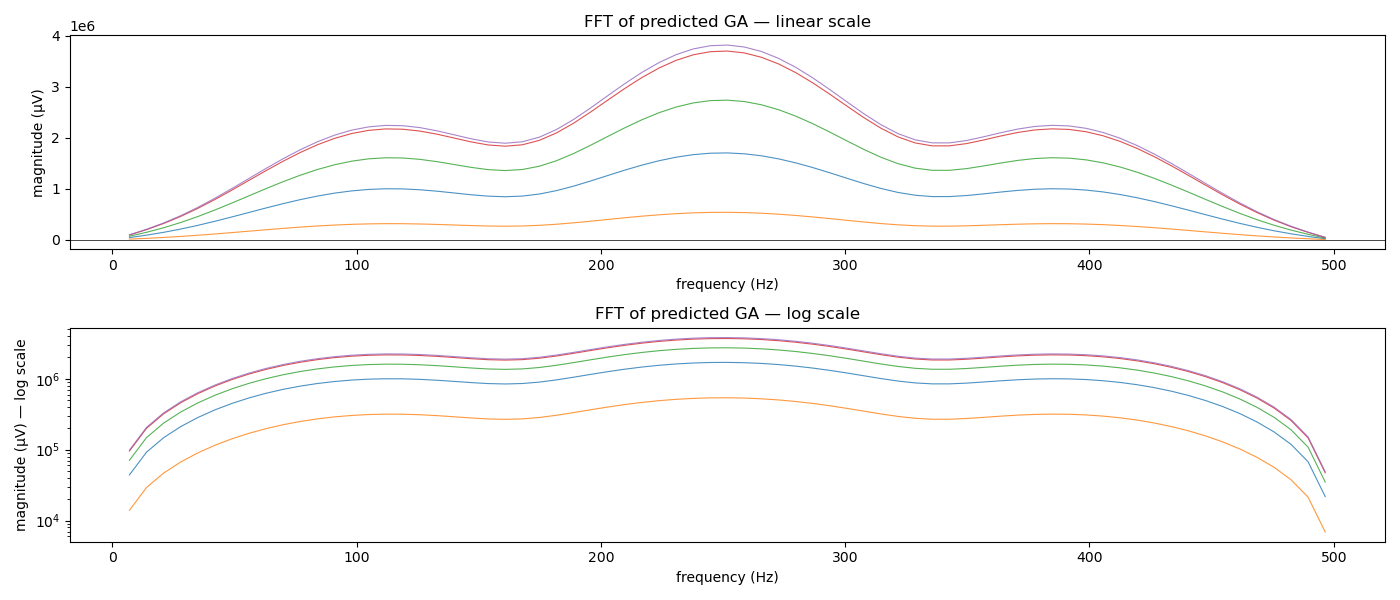

In [39]:
from scipy.fft import fft, fftfreq

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

for i in range(min(5, len(test.wires))):
    # fft of each channel's artefact waveform
    n = len(V_t[i])
    freqs = fftfreq(n, d=1/sfreq)   # frequency axis
    spectrum = np.abs(fft(V_t[i]))  # magnitude

    # only plot positive frequencies
    pos = freqs > 0
    axes[0].plot(freqs[pos], spectrum[pos], lw=0.8, alpha=0.8)
    axes[1].semilogy(freqs[pos], spectrum[pos], lw=0.8, alpha=0.8)

axes[0].set_ylabel('magnitude (µV)')
axes[0].set_title('FFT of predicted GA — linear scale')
axes[0].axhline(0, color='k', lw=0.5)
axes[0].set_xlabel('frequency (Hz)')

axes[1].set_ylabel('magnitude (µV) — log scale')
axes[1].set_title('FFT of predicted GA — log scale')
axes[1].set_xlabel('frequency (Hz)')

plt.tight_layout()
plt.show()

In [217]:
test.simulate_eeg()

Setting up raw simulation: 1 position, "cos2" interpolation
Event information not stored
    Interval 0.000–120.000 s
Setting up forward solutions


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_24912\45206209.py:94: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  self.src = mne.setup_volume_source_space(


    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    10 STC iterations provided
[done]
Adding noise to 94/94 channels (94 channels in cov)


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_24912\45206209.py:135: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  add_noise(raw_sim, cov, iir_filter=[0.2, -0.2, 0.04], random_state=rng)


Sphere                : origin at (0.0 0.0 0.0) mm
              radius  : 0.1 mm
Source location file  : dict()
Assuming input in millimeters
Assuming input in MRI coordinates

Positions (in meters) and orientations
2 sources
blink simulated and trace not stored
Setting up forward solutions


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_24912\45206209.py:137: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  add_eog(raw_sim, random_state=rng)


Using qt as 2D backend.


### Test Gradient Simulation

In [30]:
"""
EPI (Echo Planar Imaging) — PyPulseq
pip install pypulseq matplotlib numpy
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pypulseq as pp

# ══════════════════════════════════════════════
# SEQUENCE PARAMETERS
# ══════════════════════════════════════════════
FOV        = 220e-3    # m
N_RO       = 64
N_PE       = 64
SLICE_THK  = 3e-3      # m
N_SLICES   = 20
TR         = 1.5       # s
TE         = 35e-3     # s
FLIP_DEG   = 77

# Dwell must satisfy: N_RO * dwell = integer * grad_raster (10 us)
# Use 10 us -> BW = 1/(10e-6 * 64) = 1562.5 Hz/px (realistic for fMRI)
DWELL = 10e-6          # s per sample

SYSTEM = pp.Opts(
    max_grad=40, grad_unit="mT/m",
    max_slew=150, slew_unit="T/m/s",
    rf_ringdown_time=20e-6, rf_dead_time=100e-6,
    adc_dead_time=10e-6,
    grad_raster_time=10e-6,
    rf_raster_time=1e-6,
    adc_raster_time=100e-9,
    block_duration_raster=10e-6,
)

# ══════════════════════════════════════════════
# DERIVED
# ══════════════════════════════════════════════
GAMMA       = 42.577e6               # Hz/T
delta_k     = 1.0 / FOV
k_width     = N_RO * delta_k
readout_time = DWELL * N_RO          # flat-top of Gx = 640 us

# ══════════════════════════════════════════════
# EVENTS
# ══════════════════════════════════════════════
rf, gz_ss, gz_reph = pp.make_sinc_pulse(
    flip_angle=FLIP_DEG * np.pi / 180,
    duration=3e-3, slice_thickness=SLICE_THK,
    apodization=0.5, time_bw_product=4,
    system=SYSTEM, return_gz=True,
)

gx_ro = pp.make_trapezoid(
    channel="x", flat_area=k_width, flat_time=readout_time, system=SYSTEM
)
gx_ro_neg = pp.scale_grad(gx_ro, -1)

adc = pp.make_adc(
    num_samples=N_RO, duration=readout_time,
    delay=gx_ro.rise_time, system=SYSTEM
)

gx_pre = pp.make_trapezoid(channel="x", area=-gx_ro.area / 2, system=SYSTEM)

blip_dur = gx_ro.rise_time + gx_ro.fall_time
gy_blip  = pp.make_trapezoid(channel="y", area=delta_k, duration=blip_dur, system=SYSTEM)
gy_pre   = pp.make_trapezoid(channel="y", area=-N_PE / 2 * delta_k, system=SYSTEM)

# ══════════════════════════════════════════════
# TE TIMING
# ══════════════════════════════════════════════
echo_spacing = pp.calc_duration(gx_ro)

t_to_kc = (pp.calc_duration(gz_reph)
           + pp.calc_duration(gx_pre)
           + (N_PE // 2) * echo_spacing)

delay_te = TE - t_to_kc - pp.calc_duration(gz_ss) / 2
delay_te = round(delay_te / SYSTEM.block_duration_raster) * SYSTEM.block_duration_raster
assert delay_te >= 0, "TE too short"

# ══════════════════════════════════════════════
# ASSEMBLE
# ══════════════════════════════════════════════
seq = pp.Sequence(system=SYSTEM)
seq.add_block(rf, gz_ss)
seq.add_block(gz_reph, gx_pre, gy_pre, pp.make_delay(delay_te))

for line in range(N_PE):
    gx = gx_ro if line % 2 == 0 else gx_ro_neg
    if line < N_PE - 1:
        seq.add_block(gx, adc, gy_blip)
    else:
        seq.add_block(gx, adc)

t_used = (pp.calc_duration(gz_ss) + delay_te
          + pp.calc_duration(gz_reph) + N_PE * echo_spacing)
tr_delay = TR / N_SLICES - t_used
tr_delay = round(tr_delay / SYSTEM.block_duration_raster) * SYSTEM.block_duration_raster
assert tr_delay >= 0, "TR too short"
seq.add_block(pp.make_delay(tr_delay))

ok, errs = seq.check_timing()
print("Timing OK:", ok)
seq.write("epi_sequence.seq")

# ══════════════════════════════════════════════
# PRINT SUMMARY
# ══════════════════════════════════════════════
print(f"\n  Matrix       : {N_RO} x {N_PE}")
print(f"  FOV          : {FOV*1e3:.0f} mm")
print(f"  Slice thk    : {SLICE_THK*1e3:.1f} mm  x{N_SLICES}")
print(f"  TE / TR      : {TE*1e3:.0f} / {TR*1e3:.0f} ms")
print(f"  Echo spacing : {echo_spacing*1e3:.2f} ms")
print(f"  EPI train    : {N_PE * echo_spacing * 1e3:.1f} ms")
print(f"  BW per pixel : {1/DWELL/N_RO:.1f} Hz")
print(f"  Gx readout   : {gx_ro.amplitude/GAMMA*1e3:.2f} mT/m")
print(f"  Gz slice-sel : {gz_ss.amplitude/GAMMA*1e3:.2f} mT/m")

# ══════════════════════════════════════════════
# PLOT WAVEFORMS
# ══════════════════════════════════════════════
def extract_waveforms(seq):
    t_gx, gx = [0.], [0.]
    t_gy, gy = [0.], [0.]
    t_gz, gz = [0.], [0.]
    t_rf, rf_env = [], []
    adc_wins = []
    t0 = 0.0

    for blk_idx in seq.block_events:
        blk = seq.get_block(blk_idx)
        dur = pp.calc_duration(blk)

        def add_trap(ta, va, trap):
            if trap is None:
                ta += [t0, t0+dur]; va += [0., 0.]; return
            d = trap.delay if hasattr(trap, "delay") else 0.
            amp = trap.amplitude
            for tt, vv in [
                (t0, 0.), (t0+d, 0.),
                (t0+d+trap.rise_time, amp),
                (t0+d+trap.rise_time+trap.flat_time, amp),
                (t0+d+trap.rise_time+trap.flat_time+trap.fall_time, 0.),
                (t0+dur, 0.)
            ]:
                ta.append(tt); va.append(vv)

        add_trap(t_gx, gx, getattr(blk, "gx", None))
        add_trap(t_gy, gy, getattr(blk, "gy", None))
        add_trap(t_gz, gz, getattr(blk, "gz", None))

        rf_blk = getattr(blk, "rf", None)
        if rf_blk is not None:
            tpts = t0 + rf_blk.delay + rf_blk.t
            env = np.abs(rf_blk.signal)
            t_rf.extend(tpts); rf_env.extend(env / (env.max() + 1e-12))

        adc_blk = getattr(blk, "adc", None)
        if adc_blk is not None:
            ta = t0 + adc_blk.delay
            adc_wins.append((ta, ta + adc_blk.num_samples * adc_blk.dwell))

        t0 += dur

    ms = 1e3
    return (np.array(t_gx)*ms, np.array(gx)/GAMMA*1e3,
            np.array(t_gy)*ms, np.array(gy)/GAMMA*1e3,
            np.array(t_gz)*ms, np.array(gz)/GAMMA*1e3,
            np.array(t_rf)*ms, np.array(rf_env),
            [(a*ms, b*ms) for a,b in adc_wins])

t_gx,gx,t_gy,gy,t_gz,gz,t_rf,rf_env,adc_wins = extract_waveforms(seq)

fig, axes = plt.subplots(4, 1, figsize=(15, 9), sharex=True)
labels = ["RF (norm.)", "Gx (mT/m)", "Gy (mT/m)", "Gz (mT/m)"]
colors = ["#c084fc", "#60a5fa", "#34d399", "#fb923c"]
data   = [(t_rf, rf_env), (t_gx, gx), (t_gy, gy), (t_gz, gz)]

for ax, (tx, vals), col, lbl in zip(axes, data, colors, labels):
    ax.plot(tx, vals, color=col, linewidth=1.0)
    ax.fill_between(tx, vals, alpha=0.15, color=col)
    ax.axhline(0, color="#555", linewidth=0.6)
    ax.set_ylabel(lbl, fontsize=9)
    ax.grid(True, alpha=0.3, linewidth=0.4)

# shade ADC windows on Gx panel
for ta, tb in adc_wins:
    axes[1].axvspan(ta, tb, alpha=0.15, color="#34d399")

axes[3].set_xlabel("Time (ms)", fontsize=9)
fig.suptitle(f"GRE-EPI  {N_RO}x{N_PE}  FOV {FOV*1e3:.0f}mm  "
             f"TE/TR {TE*1e3:.0f}/{TR*1e3:.0f}ms  ES {echo_spacing*1e3:.2f}ms", fontsize=10)
fig.tight_layout()
plt.savefig("epi_waveforms.png", dpi=150, bbox_inches="tight")
plt.close()
print("Saved epi_waveforms.png")

C:\Users\brand\AppData\Local\Temp\ipykernel_40280\3192093615.py:49: UserWarning: Specified RF delay 0.00 us is less than the dead time 100 us. Delay was increased to the dead time.
  rf, gz_ss, gz_reph = pp.make_sinc_pulse(


Timing OK: True

  Matrix       : 64 x 64
  FOV          : 220 mm
  Slice thk    : 3.0 mm  x20
  TE / TR      : 35 / 1500 ms
  Echo spacing : 0.80 ms
  EPI train    : 51.2 ms
  BW per pixel : 1562.5 Hz
  Gx readout   : 10.68 mT/m
  Gz slice-sel : 10.44 mT/m
Saved epi_waveforms.png


In [27]:
gx

array([  0.        ,   0.        ,   0.        ,   0.        ,
         0.        , -22.60767186, -22.60767186,   0.        ,
         0.        ,   0.        ,   0.        ,  10.67584505,
        10.67584505,   0.        ,   0.        ,   0.        ,
         0.        , -10.67584505, -10.67584505,   0.        ,
         0.        ,   0.        ,   0.        ,  10.67584505,
        10.67584505,   0.        ,   0.        ,   0.        ,
         0.        , -10.67584505, -10.67584505,   0.        ,
         0.        ,   0.        ,   0.        ,  10.67584505,
        10.67584505,   0.        ,   0.        ,   0.        ,
         0.        , -10.67584505, -10.67584505,   0.        ,
         0.        ,   0.        ,   0.        ,  10.67584505,
        10.67584505,   0.        ,   0.        ,   0.        ,
         0.        , -10.67584505, -10.67584505,   0.        ,
         0.        ,   0.        ,   0.        ,  10.67584505,
        10.67584505,   0.        ,   0.        ,   0.  

## PyPulseSeq exampel script

Timing check passed successfully


i:\Software\mne\Lib\site-packages\pypulseq\utils\seq_plot.py:404: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig1 = plt.figure() if fig1 is None else fig1


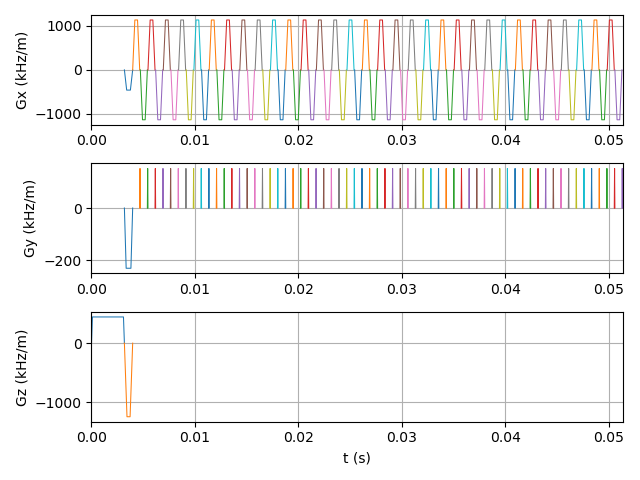

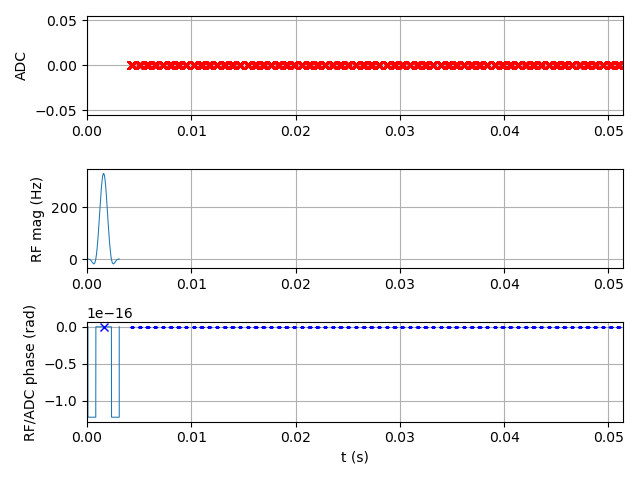

In [49]:
"""
Demo low-performance EPI sequence without ramp-sampling.
"""

import numpy as np

import pypulseq as pp


def main(
    plot: bool = False,
    test_report: bool = False,
    write_seq: bool = False,
    seq_filename: str = 'epi_pypulseq.seq',
    *,
    fov: float | tuple[float, float] = 220e-3,
    n_x: int = 64,
    n_y: int = 64,
    slice_thickness: float = 3e-3,
    n_slices: int = 1,
):
    """Create a basic EPI sequence without ramp-sampling.

    Parameters
    ----------
    plot : bool, optional
        Plot the sequence diagram. Default is False.
    test_report : bool, optional
        Print a test report. Default is False.
    write_seq : bool, optional
        Write the sequence to a .seq file. Default is False.
    seq_filename : str, optional
        Output filename for the .seq file. Default is 'epi_pypulseq.seq'.
    fov : float or tuple of float, optional
        Field of view in meters. If a single value, it is used for both x and y.
        If a tuple, it is (fov_x, fov_y). Default is 220e-3.
    n_x : int, optional
        Number of readout samples. Default is 64.
    n_y : int, optional
        Number of phase encoding steps. Default is 64.
    slice_thickness : float, optional
        Slice thickness in meters. Default is 3e-3.
    n_slices : int, optional
        Number of slices. Default is 3.

    Returns
    -------
    seq : pypulseq.Sequence
        The EPI sequence object.
    """
    fov_x, fov_y = (fov, fov) if isinstance(fov, (int, float)) else fov

    # Set system limits
    system = pp.Opts(
        max_grad=32,
        grad_unit='mT/m',
        max_slew=130,
        slew_unit='T/m/s',
        rf_ringdown_time=30e-6,
        rf_dead_time=100e-6,
    )

    seq = pp.Sequence(system)

    # Create 90 degree slice selection pulse and gradient
    rf, gz, _ = pp.make_sinc_pulse(
        flip_angle=np.pi / 2,
        system=system,
        duration=3e-3,
        slice_thickness=slice_thickness,
        apodization=0.5,
        time_bw_product=4,
        return_gz=True,
        delay=system.rf_dead_time,
        use='excitation',
    )

    # Define other gradients and ADC events
    delta_kx = 1 / fov_x
    delta_ky = 1 / fov_y
    k_width = n_x * delta_kx
    adc_dwell = 4e-6
    adc_duration = n_x * adc_dwell
    gx_flat_time = adc_duration
    gx_flat_time = np.ceil(gx_flat_time * 1e5) * 1e-5  # Round-up to the gradient raster
    gx = pp.make_trapezoid(
        channel='x',
        system=system,
        amplitude=k_width / adc_duration,
        flat_time=gx_flat_time,
    )
    adc = pp.make_adc(
        num_samples=n_x,
        duration=adc_duration,
        delay=gx.rise_time + gx_flat_time / 2 - (adc_duration - adc_dwell) / 2,
    )

    # Pre-phasing gradients
    pre_time = 8e-4
    gx_pre = pp.make_trapezoid(channel='x', system=system, area=-gx.area / 2, duration=pre_time)
    gz_reph = pp.make_trapezoid(channel='z', system=system, area=-gz.area / 2, duration=pre_time)
    gy_pre = pp.make_trapezoid(channel='y', system=system, area=-n_y / 2 * delta_ky, duration=pre_time)

    # Phase blip in the shortest possible time
    gy_blip_duration = 2 * np.sqrt(delta_ky / system.max_slew)
    gy_blip_duration = np.ceil(gy_blip_duration / 10e-6) * 10e-6
    gy = pp.make_trapezoid(channel='y', system=system, area=delta_ky, duration=gy_blip_duration)

    # Loop over slices
    for i_slice in range(n_slices):
        rf.freq_offset = gz.amplitude * slice_thickness * (i_slice - (n_slices - 1) / 2)
        seq.add_block(rf, gz)
        seq.add_block(gx_pre, gy_pre, gz_reph)
        for _ in range(n_y):
            seq.add_block(gx, adc)  # Read one line of k-space
            seq.add_block(gy)  # Phase blip
            gx.amplitude = -gx.amplitude  # Reverse polarity of read gradient

    ok, error_report = seq.check_timing()
    if ok:
        print('Timing check passed successfully')
    else:
        print('Timing check failed. Error listing follows:')
        [print(e) for e in error_report]

    if test_report:
        print(seq.test_report())

    if plot:
        seq.plot()

    seq.set_definition(key='FOV', value=[fov_x, fov_y, slice_thickness * n_slices])
    seq.set_definition(key='Name', value='epi')

    if write_seq:
        seq.write(seq_filename)

    return seq


if __name__ == '__main__':
    main(plot=True, write_seq=True)

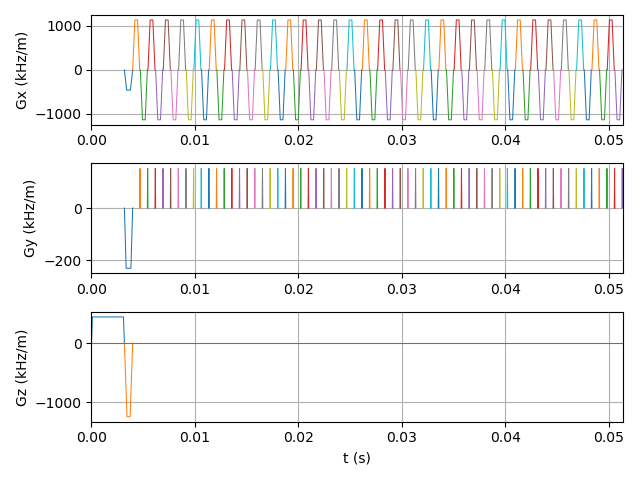

In [50]:
plt.plot(gy)
plt.show()

In [61]:
import pypulseq as pp

seq = pp.Sequence()
seq.read('epi_pypulseq.seq')

In [73]:
x = seq.waveforms()

In [79]:
plt.plot(x[0])

In [84]:
x,y,z,rf,adc = seq.waveforms_and_times()

In [91]:
seq.get_gradients()

In [155]:
gw_pp = seq.get_gradients()   # list of 3 PPoly objects [Gx, Gy, Gz]
duration = seq.duration()[0]
sfreq = 100000
t = np.arange(0, duration, 1/sfreq)
Gx = gw_pp[0](t)
Gy = gw_pp[1](t)
Gz = gw_pp[2](t)
    
# replace nans with zeros (outside sequence = no gradient)
Gx = np.nan_to_num(Gx)
Gy = np.nan_to_num(Gy)
Gz = np.nan_to_num(Gz)


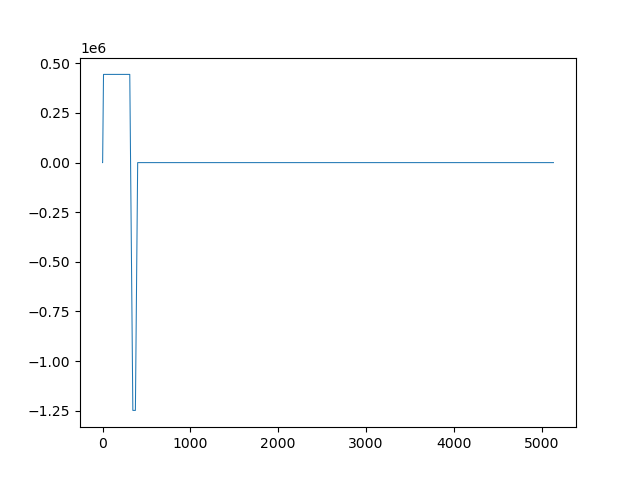

In [163]:
plt.close()
a = plt.plot(Gz)
plt.show()

In [142]:
plt.close()

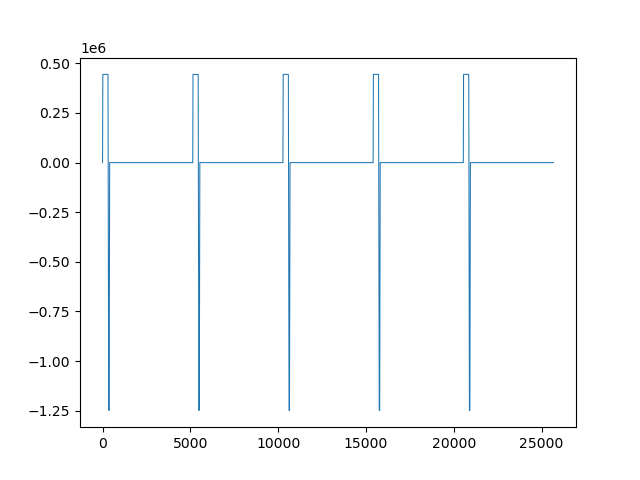

In [184]:
Gz_new = np.tile(Gz, 5)
test = plt.plot(Gz_new)
plt.show()

In [176]:
len(Gz)

5135

In [183]:
plt.close()